In [2]:
import pickle
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
import seaborn as sns
from mne.decoding import CSP

In [3]:
# data_file_path = "../data/20250512/processed/ishii_merged.pkl"
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"
# data_file_path = "../../data/bcidatasetIV2a/processed/merged.pkl"

In [4]:
# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs'] # エポックデータ
epochs_list = epochs.get_data()  # エポックデータをリスト形式で取得
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス
fs = 250

In [5]:
# labelsが9999のものを除外する
valid_indices = np.where(labels != 9999)[0]
# epochs_list = epochs_list[valid_indices]
labels = labels[valid_indices]

In [6]:
epochs_list.shape

(60, 63, 12501)

In [7]:
labels.shape

(60,)

In [8]:
# 1チャンネルのデータをDFTしてバンドパスパワーを計算
def calc_spectrum(data, band_count, fs):
    n = len(data)
    freq = np.fft.fftfreq(n, 1/fs)
    spectrum = np.fft.fft(data)
    # 1Hz-40Hzまでの4Hzごとのバンドパスパワーを計算
    band_lower = 0
    band_upper = 40
    band_powers = [None] * band_count
    for i in range(band_count):
        band = band_lower+i*(band_upper-band_lower)/band_count, band_lower+(i+1)*(band_upper-band_lower)/band_count
        band_power = np.sum(np.abs(spectrum[(freq >= band[0]) & (freq < band[1])])**2)
        band_powers[i] = band_power
    
    # band_powersの中にNoneがないことをassert
    # assert all([v is not None for v in band_powers]), "Some band powers are None"
    assert all(band_powers), "Some band powers are None"
    return band_powers

In [9]:
# 時間方向を6等分し、それぞれのウィンドウでFFTを計算する関数
def calc_windowed_spectrum(data, band_count, fs, window_count=6):
    n = len(data)
    window_size = n // window_count
    all_band_powers = []
    
    for i in range(window_count):
        # ウィンドウの開始位置と終了位置を計算
        start_idx = i * window_size
        end_idx = (i + 1) * window_size if i < window_count - 1 else n
        
        # 現在のウィンドウのデータを取得
        window_data = data[start_idx:end_idx]
        
        # 現在のウィンドウでFFTを計算
        window_band_powers = calc_spectrum(window_data, band_count, fs)
        
        # 結果を追加
        all_band_powers.extend(window_band_powers)
    
    return all_band_powers

In [10]:
e0 = epochs_list[0, :, :]
e0c0 = epochs_list[0, 0, :]
e0c0

array([-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
       -3.94677566e-06, -3.60453253e-06, -3.26022334e-06])

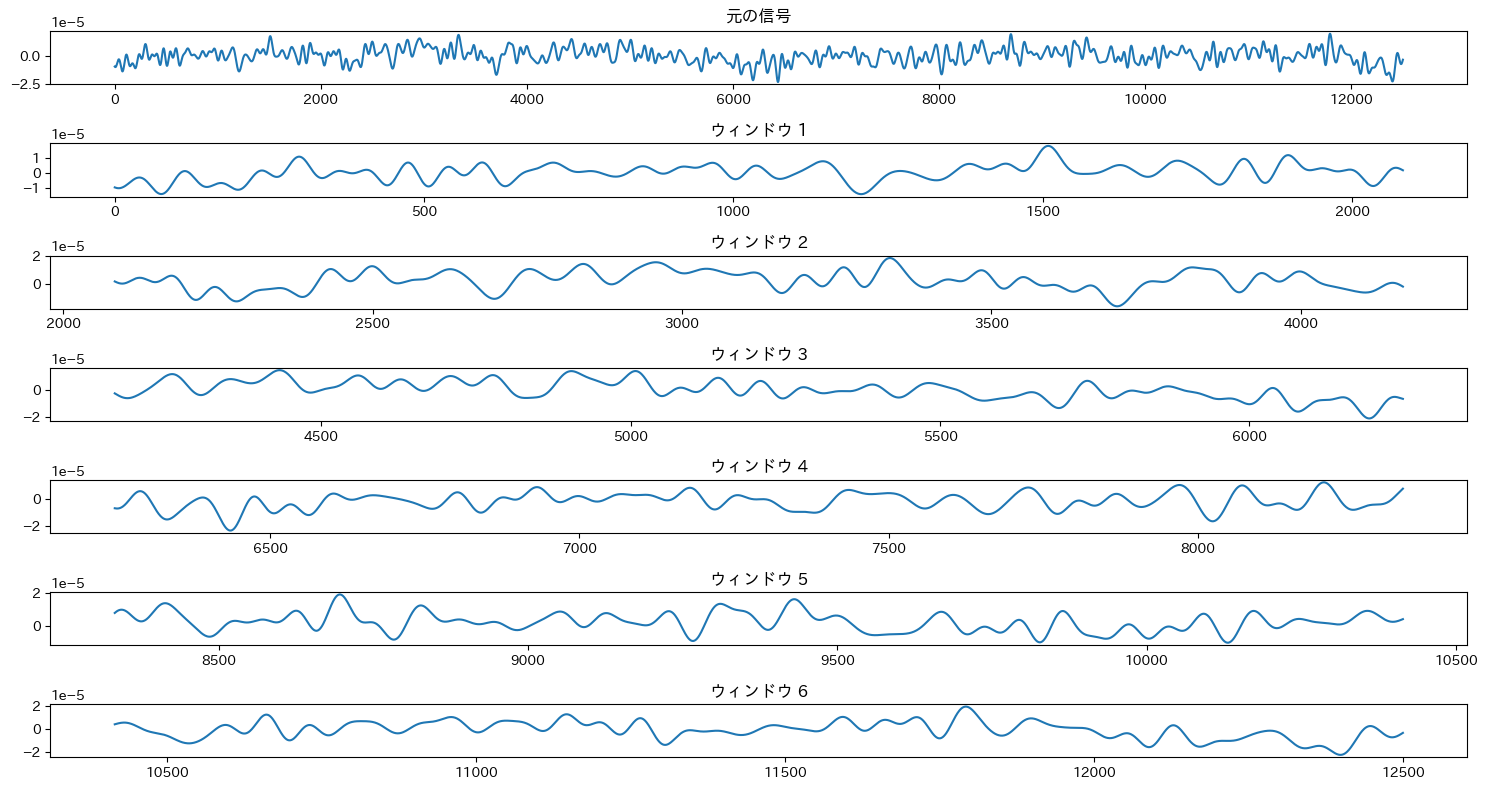

In [11]:
# 最初のエポックの最初のチャンネルのデータを6つのウィンドウに分割して可視化
window_count = 6

first_epoch_data = epochs_list[0, 0, :]
n = len(first_epoch_data)
window_size = n // window_count

plt.figure(figsize=(15, 8))
# 元の信号を表示
plt.subplot(window_count+1, 1, 1)
plt.plot(first_epoch_data)
plt.title('元の信号')

# 各ウィンドウを表示
for i in range(window_count):
    start_idx = i * window_size
    end_idx = (i + 1) * window_size if i < window_count - 1 else n
    
    plt.subplot(window_count+1, 1, i+2)
    plt.plot(range(start_idx, end_idx), first_epoch_data[start_idx:end_idx])
    plt.title(f'ウィンドウ {i+1}')
    
plt.tight_layout()
plt.show()

In [12]:
calc_windowed_spectrum(e0c0, 10, fs, 6)

[5.6357936331322904e-05,
 6.949536860991833e-06,
 7.032663391842872e-08,
 3.49888876983879e-08,
 2.014052638171087e-08,
 1.3497904757504033e-08,
 9.981112677101948e-09,
 7.3215920043423855e-09,
 5.776720653220436e-09,
 4.824666889083641e-09,
 0.000122233657469586,
 1.8538610909548707e-06,
 8.591241538662389e-09,
 4.5781152139988275e-09,
 2.6961293379671497e-09,
 1.8249530124760592e-09,
 1.357119101059812e-09,
 9.988392869446235e-10,
 7.899366674079808e-10,
 6.607896035802619e-10,
 0.00010200774347686689,
 1.271293764830098e-06,
 1.2715405974639518e-08,
 5.885109443302843e-09,
 3.299204711367963e-09,
 2.1848934060972117e-09,
 1.6044309501699938e-09,
 1.1718126355596416e-09,
 9.219814227712124e-10,
 7.685613405198495e-10,
 8.819500883053829e-05,
 2.7332503019651167e-06,
 1.3191349990873115e-07,
 6.29565741333951e-08,
 3.581040772829888e-08,
 2.3869783494110702e-08,
 1.7595001107543065e-08,
 1.2884776490932637e-08,
 1.0154241689976052e-08,
 8.473998697690748e-09,
 8.79132200950619e-05,
 5

In [13]:
# epochs_list[0]の各チャンネルのDFTを計算
def calc_spectrum_all_channels(epoch, band_count, fs, window_count=6):
    n_channels = epoch.shape[0]
    # 各チャンネルにつき、band_count × window_count の特徴量を格納するように変更
    band_powers = np.zeros((n_channels, band_count * window_count))
    for i in range(n_channels):
        band_powers[i] = calc_windowed_spectrum(epoch[i, :], band_count, fs, window_count)
    return band_powers

In [14]:
epochs_list

array([[[-9.30949766e-06, -9.46138806e-06, -9.58895937e-06, ...,
         -3.94677566e-06, -3.60453253e-06, -3.26022334e-06],
        [-6.61819783e-06, -6.67719987e-06, -6.72905247e-06, ...,
         -4.93273802e-06, -4.60791761e-06, -4.26894912e-06],
        [-1.14789266e-05, -1.14936513e-05, -1.15076565e-05, ...,
         -7.45696650e-06, -7.30558514e-06, -7.13490628e-06],
        ...,
        [-8.68024392e-06, -8.88847776e-06, -9.08003784e-06, ...,
         -7.44699476e-06, -7.11538511e-06, -6.76824569e-06],
        [ 7.86079327e-06,  7.66818884e-06,  7.43821140e-06, ...,
         -5.81038970e-06, -5.01818565e-06, -4.21080287e-06],
        [-4.35543682e-06, -4.40796432e-06, -4.45664434e-06, ...,
         -5.51612633e-06, -5.00906389e-06, -4.48585655e-06]],

       [[-4.64347313e-06, -4.64497821e-06, -4.66000783e-06, ...,
         -3.24555059e-06, -3.00362235e-06, -2.74540713e-06],
        [ 5.66985197e-06,  5.74854965e-06,  5.79338440e-06, ...,
         -1.77540176e-06, -1.79361111e

In [15]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import multiprocessing

band_count = 10
window_count = 6
# 特徴量の次元を更新（window_count倍に）
all_epochs_band_powers = np.zeros((epochs_list.shape[0], epochs_list.shape[1], band_count * window_count))

# 各エポックを処理する関数
def process_epoch(i):
    return calc_spectrum_all_channels(epochs_list[i], band_count, fs, window_count)

# 使用するCPUコア数を設定（-1は全コアを使用）
n_jobs = multiprocessing.cpu_count()
print(f"使用するCPUコア数: {n_jobs}")

# tqdmでプログレスバーを表示しながら並列処理
results = Parallel(n_jobs=n_jobs, verbose=0)(
    delayed(process_epoch)(i) for i in tqdm(range(epochs_list.shape[0]), desc='エポック処理中')
)

# 結果を配列に格納
for i, result in enumerate(results):
    all_epochs_band_powers[i] = result

使用するCPUコア数: 8


エポック処理中:   0%|          | 0/60 [00:00<?, ?it/s]

In [16]:
# 特徴量を2次元配列に変換（サンプル数×特徴量）
# 31*20=620の特徴量を持つ40個のデータに変換
X = all_epochs_band_powers.reshape(all_epochs_band_powers.shape[0], -1)
print(f"特徴量のshape: {X.shape}")
print(f"ラベルのshape: {labels.shape}")

特徴量のshape: (60, 3780)
ラベルのshape: (60,)


In [17]:
# 特徴量を2次元配列に変換（サンプル数×特徴量）
# 各チャンネルにつき10個のバンドパワー × 6個のウィンドウ
# つまり、チャンネル数 × 10 × 6 の特徴量を持つデータに変換
X = all_epochs_band_powers.reshape(all_epochs_band_powers.shape[0], -1)
print(f"特徴量のshape: {X.shape}")
print(f"ラベルのshape: {labels.shape}")

# トレーニングデータとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42, stratify=labels)

特徴量のshape: (60, 3780)
ラベルのshape: (60,)


In [18]:
# 特徴量のスケーリング
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# データの形状を確認
print(f"epochs_listの形状: {epochs_list.shape}")
print(f"labelsの形状: {labels.shape}")
print(f"ユニークなラベル: {np.unique(labels)}")

# 有効なインデックスでepochs_listもフィルタリング
epochs_filtered = epochs_list[valid_indices]
print(f"フィルタリング後のepochs形状: {epochs_filtered.shape}")
print(f"フィルタリング後のlabels形状: {labels.shape}")

# EEGデータの基本統計
print(f"\nEEGデータの統計:")
print(f"最小値: {epochs_filtered.min():.4f}")
print(f"最大値: {epochs_filtered.max():.4f}")
print(f"平均値: {epochs_filtered.mean():.4f}")
print(f"標準偏差: {epochs_filtered.std():.4f}")

epochs_listの形状: (60, 63, 12501)
labelsの形状: (60,)
ユニークなラベル: [1 2]
フィルタリング後のepochs形状: (60, 63, 12501)
フィルタリング後のlabels形状: (60,)

EEGデータの統計:
最小値: -0.0001
最大値: 0.0001
平均値: -0.0000
標準偏差: 0.0000


In [20]:
# CSPによる特徴量抽出（MNE-Pythonを使用）
n_components = 6  # 抽出する成分数

# データを訓練用とテスト用に分割（CSP学習用）
X_train_raw, X_test_raw, y_train_csp, y_test_csp = train_test_split(
    epochs_filtered, labels, test_size=0.3, random_state=42, stratify=labels
)

# データをfloat64に変換してCSPのエラーを回避
X_train_raw = X_train_raw.astype(np.float64)
X_test_raw = X_test_raw.astype(np.float64)

print(f"訓練データの形状: {X_train_raw.shape}")
print(f"テストデータの形状: {X_test_raw.shape}")
print(f"データ型: {X_train_raw.dtype}")
print(f"ユニークなラベル: {np.unique(y_train_csp)}")

# CSPインスタンスを作成（copy=Trueを明示的に指定）
csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False)

print("CSPフィルタを学習中...")
# CSPフィルタを学習
csp.fit(X_train_raw, y_train_csp)

print("CSP特徴量を抽出中...")
# CSP特徴量を抽出
X_train_csp = csp.transform(X_train_raw)
X_test_csp = csp.transform(X_test_raw)

print(f"CSP特徴量（訓練）の形状: {X_train_csp.shape}")
print(f"CSP特徴量（テスト）の形状: {X_test_csp.shape}")

# CSPパターンの可視化（最初の4成分）
patterns = csp.patterns_
print(f"CSPパターンの形状: {patterns.shape}")
print("CSP特徴量抽出完了！")

訓練データの形状: (42, 63, 12501)
テストデータの形状: (18, 63, 12501)
データ型: float64
ユニークなラベル: [1 2]
CSPフィルタを学習中...
Computing rank from data with rank=None
    Using tolerance 0.00039 (2.2e-16 eps * 63 dim * 2.8e+10  max singular value)
    Estimated rank (data): 34
    data: rank 34 computed from 63 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 34
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
CSP特徴量を抽出中...
CSP特徴量（訓練）の形状: (42, 6)
CSP特徴量（テスト）の形状: (18, 6)
CSPパターンの形状: (34, 63)
CSP特徴量抽出完了！


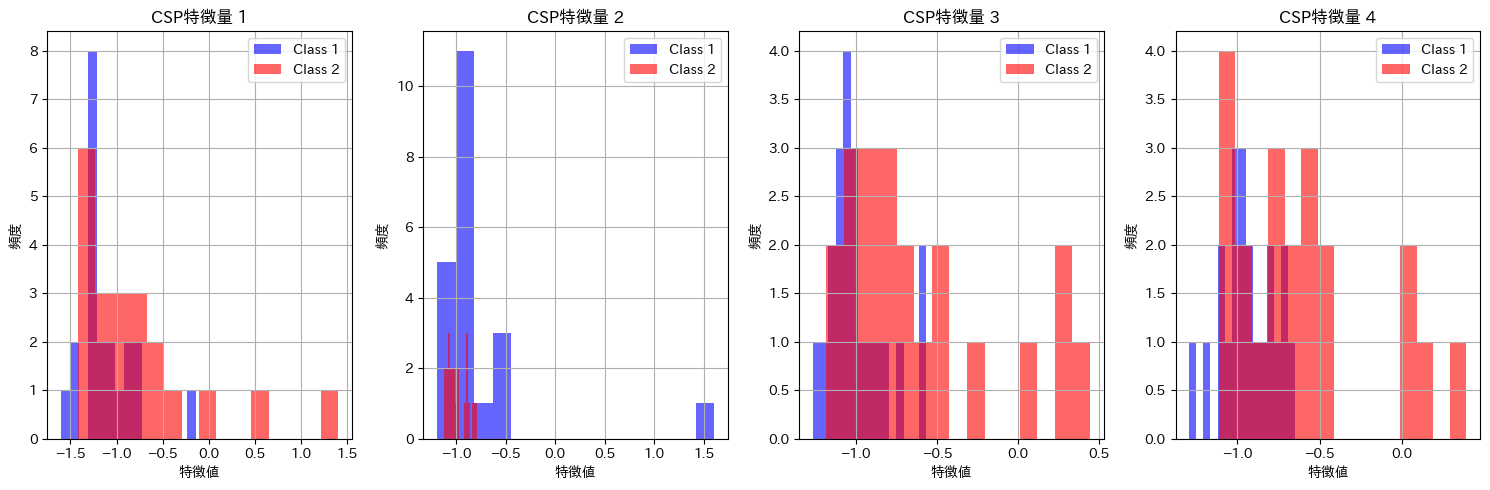

In [39]:
# CSP特徴量の可視化
plt.figure(figsize=(15, 5))

# 2. 各クラスのCSP特徴量分布
colors = ['blue', 'red']
class_names = [f'Class {int(c)}' for c in np.unique(y_train_csp)]

for i in range(min(4, X_train_csp.shape[1])):
    plt.subplot(1, 4, i+1)
    for j, class_label in enumerate(np.unique(y_train_csp)):
        class_features = X_train_csp[y_train_csp == class_label, i]
        plt.hist(class_features, alpha=0.6, bins=15, color=colors[j], 
                label=class_names[j])
    plt.title(f'CSP特徴量 {i+1}')
    plt.xlabel('特徴値')
    plt.ylabel('頻度')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

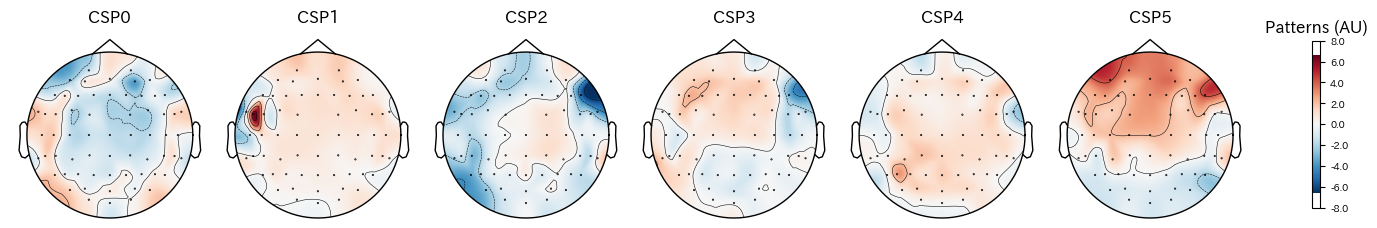

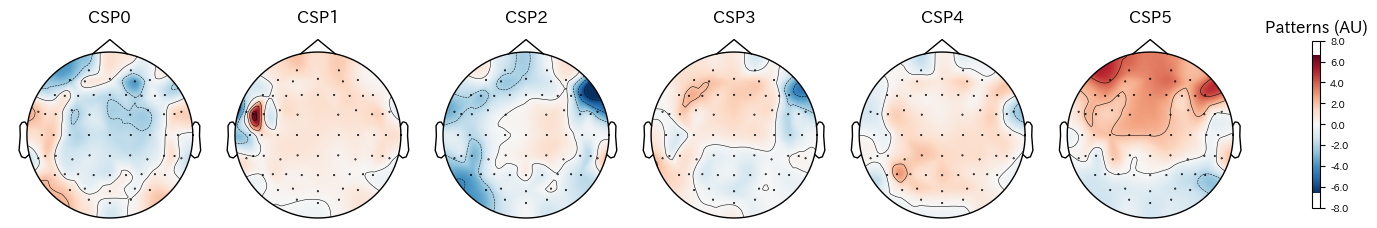

In [22]:
csp.plot_patterns(epochs.info, ch_type="eeg", units="Patterns (AU)", size=1.5)

In [33]:
# CSP特徴量のスケーリング
scaler_csp = StandardScaler()
X_train_csp_scaled = scaler_csp.fit_transform(X_train_csp)
X_test_csp_scaled = scaler_csp.transform(X_test_csp)

# CSP特徴量でSVM分類
svm_csp = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_csp.fit(X_train_csp_scaled, y_train_csp)

# 予測
y_pred_csp = svm_csp.predict(X_test_csp_scaled)

# 評価
print("=== CSP特徴量による分類結果 ===")
print("分類レポート:")
print(classification_report(y_test_csp, y_pred_csp))

# クロスバリデーション
cv_scores_csp = cross_val_score(svm_csp, X_train_csp_scaled, y_train_csp, cv=5)
print(f"\nクロスバリデーションスコア: {cv_scores_csp}")
print(f"平均精度: {cv_scores_csp.mean():.4f} ± {cv_scores_csp.std():.4f}")

=== CSP特徴量による分類結果 ===
分類レポート:
              precision    recall  f1-score   support

           1       0.42      0.56      0.48         9
           2       0.33      0.22      0.27         9

    accuracy                           0.39        18
   macro avg       0.38      0.39      0.37        18
weighted avg       0.38      0.39      0.37        18


クロスバリデーションスコア: [0.77777778 0.55555556 0.875      0.75       0.75      ]
平均精度: 0.7417 ± 0.1038


In [24]:
# 元のFFT特徴量との比較（比較用）
print("\n=== 元のFFT特徴量との比較 ===")

# 元のFFT特徴量を同じデータ分割で評価
X_train_fft = X_train  # 既に計算済み
X_test_fft = X_test    # 既に計算済み
y_train_fft = y_train  # 既に計算済み
y_test_fft = y_test    # 既に計算済み

print(f"FFT特徴量の次元: {X_train_fft.shape[1]}")
print(f"CSP特徴量の次元: {X_train_csp.shape[1]}")
print(f"次元削減率: {X_train_csp.shape[1] / X_train_fft.shape[1] * 100:.1f}%")

# 既存のSVMモデルでの性能を再確認
# まずbest_svmが定義されていない場合は、簡単なモデルで代用
try:
    y_pred_fft = best_svm.predict(X_test_scaled)
except NameError:
    # best_svmが定義されていない場合の代替
    temp_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    temp_svm.fit(X_train_scaled, y_train)
    y_pred_fft = temp_svm.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_fft = accuracy_score(y_test_fft, y_pred_fft)
accuracy_csp = accuracy_score(y_test_csp, y_pred_csp)

print(f"\nFFT特徴量の精度: {accuracy_fft:.4f}")
print(f"CSP特徴量の精度: {accuracy_csp:.4f}")
print(f"精度の差: {accuracy_csp - accuracy_fft:.4f}")

# CSPのハイパーパラメータチューニング
print("\n=== CSPハイパーパラメータチューニング ===")
from sklearn.pipeline import Pipeline

# 異なるCSP成分数でテスト
csp_components = [4, 6, 8, 10]
best_score = 0
best_n_components = 4

# データをfloat64に変換（パイプライン用）
X_train_raw_float64 = X_train_raw.astype(np.float64)

for n_comp in csp_components:
    print(f"CSP成分数 {n_comp} でテスト中...")
    
    # CSP + SVM パイプライン
    pipe = Pipeline([
        ('csp', CSP(n_components=n_comp, reg=None, log=True, norm_trace=False)),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ])
    
    try:
        # クロスバリデーション
        cv_scores = cross_val_score(pipe, X_train_raw_float64, y_train_csp, cv=5, n_jobs=1)
        mean_score = cv_scores.mean()
        
        print(f"CSP成分数 {n_comp}: {mean_score:.4f} ± {cv_scores.std():.4f}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_n_components = n_comp
    except Exception as e:
        print(f"CSP成分数 {n_comp}: エラー - {str(e)[:50]}...")
        continue

print(f"\n最適CSP成分数: {best_n_components}")
print(f"最高スコア: {best_score:.4f}")


=== 元のFFT特徴量との比較 ===
FFT特徴量の次元: 3780
CSP特徴量の次元: 6
次元削減率: 0.2%

FFT特徴量の精度: 0.6111
CSP特徴量の精度: 0.3889
精度の差: -0.2222

=== CSPハイパーパラメータチューニング ===
CSP成分数 4 でテスト中...


Computing rank from data with rank=None
    Using tolerance 0.00034 (2.2e-16 eps * 63 dim * 2.5e+10  max singular value)
    Estimated rank (data): 34
    data: rank 34 computed from 63 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 34
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00035 (2.2e-16 eps * 63 dim * 2.5e+10  max singular value)
    Estimated rank (data): 34
    data: rank 34 computed from 63 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 34
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00035 (2.2e-16 eps * 63 dim * 2.5e+10  max singular value)
    Estimated rank (data): 34
    data: rank 34 compute

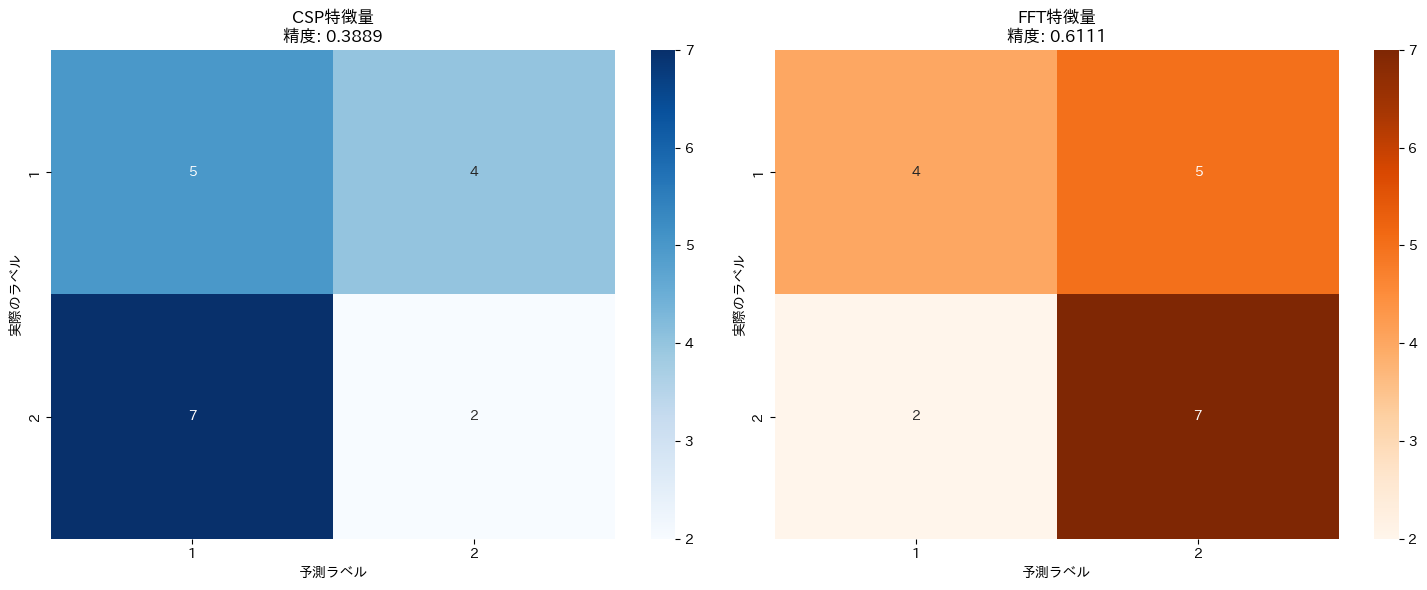

In [25]:
# 混同行列の比較
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CSP特徴量の混同行列
cm_csp = confusion_matrix(y_test_csp, y_pred_csp)
sns.heatmap(cm_csp, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=np.unique(labels), 
           yticklabels=np.unique(labels))
axes[0].set_xlabel('予測ラベル')
axes[0].set_ylabel('実際のラベル')
axes[0].set_title(f'CSP特徴量\n精度: {accuracy_csp:.4f}')

# FFT特徴量の混同行列
cm_fft = confusion_matrix(y_test_fft, y_pred_fft)
sns.heatmap(cm_fft, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
           xticklabels=np.unique(labels), 
           yticklabels=np.unique(labels))
axes[1].set_xlabel('予測ラベル')
axes[1].set_ylabel('実際のラベル')
axes[1].set_title(f'FFT特徴量\n精度: {accuracy_fft:.4f}')

plt.tight_layout()
plt.show()

In [26]:
# SVMモデルの作成と学習
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# テストデータで予測
y_pred = svm.predict(X_train_scaled)

# 評価
print("分類レポート:")
# print(classification_report(y_test, y_pred))# ラベルの分布を確認
print(classification_report(y_train, y_pred))# ラベルの分布を確認
unique_labels, counts = np.unique(labels, return_counts=True)
print("ラベルの分布:")
for label, count in zip(unique_labels, counts):
    print(f"ラベル {label}: {count}個")

分類レポート:
              precision    recall  f1-score   support

           1       0.95      1.00      0.98        21
           2       1.00      0.95      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42

ラベルの分布:
ラベル 1: 30個
ラベル 2: 30個


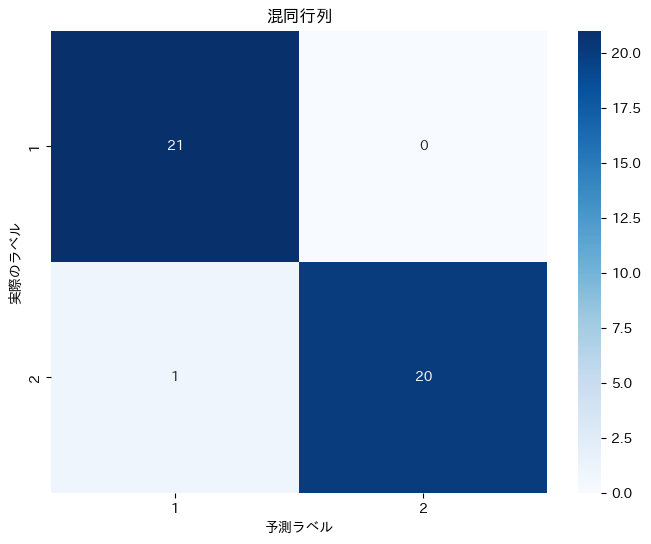

In [27]:
# 混同行列の表示
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=unique_labels, 
           yticklabels=unique_labels)
plt.xlabel('予測ラベル')
plt.ylabel('実際のラベル')
plt.title('混同行列')
plt.show()

クロスバリデーションスコア: [0.6  0.4  0.5  0.5  0.75 0.5  0.5  0.25 0.5  0.5 ]
平均精度: 0.5000 ± 0.1204


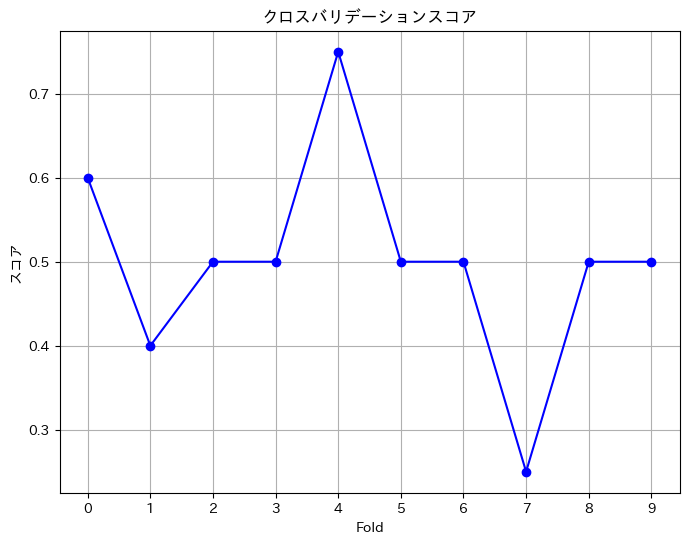

In [28]:
# クロスバリデーションで評価
cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=10)
print(f"クロスバリデーションスコア: {cv_scores}")
print(f"平均精度: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
# クロスバリデーションの結果をプロット
plt.figure(figsize=(8, 6))
plt.plot(cv_scores, marker='o', linestyle='-', color='b')
plt.title('クロスバリデーションスコア')
plt.xlabel('Fold')
plt.ylabel('スコア')
plt.xticks(range(len(cv_scores)))
plt.grid()
plt.show()

In [29]:
# ハイパーパラメータチューニング
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"最適パラメータ: {grid_search.best_params_}")
print(f"最高スコア: {grid_search.best_score_:.4f}")


最適パラメータ: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
最高スコア: 0.5550


最適モデルのクロスバリデーションスコア: [0.4  0.4  0.5  0.75 0.25 0.75 0.75 0.5  0.75 0.5 ]
最適モデルの平均精度: 0.5550 ± 0.1739
最適モデルの分類レポート:
              precision    recall  f1-score   support

           1       0.50      0.33      0.40         9
           2       0.50      0.67      0.57         9

    accuracy                           0.50        18
   macro avg       0.50      0.50      0.49        18
weighted avg       0.50      0.50      0.49        18



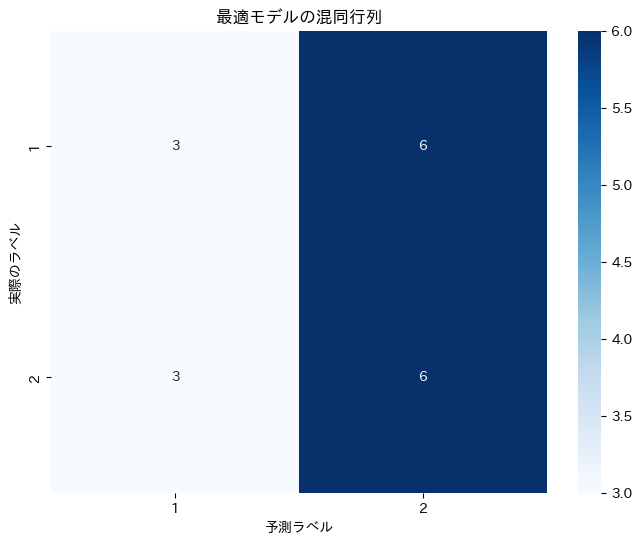

In [30]:
# 最適なモデルで評価
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

# 最適なモデルのCVスコアを計算
best_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=10)
print(f"最適モデルのクロスバリデーションスコア: {best_cv_scores}")
print(f"最適モデルの平均精度: {best_cv_scores.mean():.4f} ± {best_cv_scores.std():.4f}")

print("最適モデルの分類レポート:")
print(classification_report(y_test, y_pred_best))

# 混同行列の表示
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
           xticklabels=unique_labels, 
           yticklabels=unique_labels)
plt.xlabel('予測ラベル')
plt.ylabel('実際のラベル')
plt.title('最適モデルの混同行列')
plt.show()